In [1]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd

color_palette = {}
color_palette['wt'] = 'blue'
color_palette['mutated'] = 'red'
color_palette['heterozygous'] = 'orange'

import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils
large_data_dir = gf_utils.large_data_dir


In [2]:
adata_dir = large_data_dir + 'MPN_WTA/MPN_1_BC007_genotyped.h5ad'
adata = sc.read_h5ad(adata_dir)


In [3]:
def assign_genotypes_removed(adata, max_p=1.0):
    variants = []
    cols = adata.obsm['genotypes'].columns
    for col in cols:
        if 'high_confidence_counts' in col:
            variant = col.replace('_high_confidence_counts', '')
            variants.append(variant)
    for variant in variants:
        variant_cols = [col for col in cols if col.startswith(variant)]
        variant_cols = [col for col in variant_cols if col.endswith('_mutated') or col.endswith('_wt') or col.endswith('_heterozygous')]
        max_probs = adata.obsm['genotypes'][variant_cols].dropna().max(axis=1)
        n_counts = adata.obsm['genotypes'][variant + '_high_confidence_counts']
        genotypes = adata.obsm['genotypes'][variant_cols].dropna().idxmax(axis=1)
        genotypes = genotypes[(max_probs <= max_p) | (n_counts == 0)]
        genotypes = genotypes.str.replace(variant + '_', '')
        if 'genotype_call' not in adata.obsm:
            adata.obsm['genotype_call'] = pd.DataFrame(index=adata.obs_names)
        adata.obsm['genotype_call'][variant] = genotypes


CALR c.1150_1154delinsTGTC 3149
NRAS c.35G>A 2950
ZRSR2 c.883C>T 1134
TP53 c.818G>A 3129
EZH2 c.2054G>A 1437


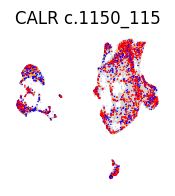

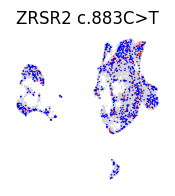

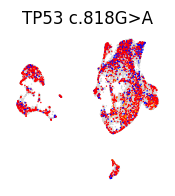

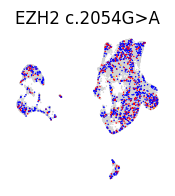

In [4]:
assign_genotypes_removed(adata, max_p=0.6)

for variant in adata.obsm['genotype_call'].columns[0:5]:
    adata.obs[variant + '_call'] = adata.obsm['genotype_call'][variant] 
    print(variant, adata.obs[variant + '_call'].notna().sum()) ## check number of cells genotyped

    if variant == 'NRAS c.35G>A':
        continue
    
    fig,ax = plt.subplots(figsize=(2,2))
    sc.pl.umap(adata, color = variant + '_call', palette=color_palette, frameon=False, ax=ax, show=False, legend_loc=None,title = variant[0:15])
    plt.savefig('../plots/removed_cell_genotypes_' + variant.replace(' ', '_') + '_genotyping.pdf', bbox_inches='tight')